In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import  DataLoader,Subset
import torch.optim as optim
from torchsummary import summary
import torch.nn.functional as F
from torch.autograd.functional import jacobian
from torchvision import transforms,datasets
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device= torch.device ('cuda'if torch.cuda.is_available() else 'cpu')


In [15]:
transform=transforms.Compose([transforms.Resize((64,64)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5),
                                                   (0.5))])
train_dataset=datasets.MNIST(root='data',
                             train=True,
                             download=True,
                             transform=transform)

subset_indices=list(range(20000))
subset_data_set=Subset(train_dataset,subset_indices)

data_loader = DataLoader(subset_data_set,batch_size=100,shuffle=True)


In [16]:
class UnetAutoEncoder(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    #Encoder
    self.encoder_=nn.Sequential(
        #Encoder 1
        nn.Conv2d(input_features,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(64,64,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 2
        nn.MaxPool2d(2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(128,128,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 3
        nn.MaxPool2d(2),
        nn.Conv2d(128,256,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 4
        nn.MaxPool2d(2),
        nn.Conv2d(256,512,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(512,512,kernel_size=3,padding=1),
        nn.ReLU()
    )

    #Bottleneck
    self.bottleneck_=nn.Sequential(
        nn.MaxPool2d(2),
        nn.Conv2d(512,1024,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(1024,1024,kernel_size=3,padding=1),
        nn.ReLU()
    )
    #Decoder
    self.decoder_= nn.Sequential(#Decoder 1
            nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 2
            nn.ConvTranspose2d(512,256,kernel_size=2,stride=2),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 3
            nn.ConvTranspose2d(256,128,kernel_size=2,stride=2),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 4
            nn.ConvTranspose2d(128,64,kernel_size=2,stride=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),

            #output Layer
            nn.Conv2d(64,1,kernel_size=1)
            )

  def forward(self,x):
    self.activation=[] #Cache activation
    self.w_squarred=[] #Cache weight Norms

    current_x=x

    for layer in self.encoder_:
            if isinstance (layer,nn.Conv2d):
                current_x=layer(current_x)
                w=layer.weight
                self.w_squarred=w.pow(2).sum([1,2,3]) #output channels
            elif isinstance(layer,nn.ReLU):
                current_x=layer(current_x)
                self.activation.append(current_x)
            elif isinstance(layer,nn.MaxPool2d):
                current_x=layer(current_x)
            else:
                current_x=layer(current_x)

    x=current_x
    encoder=x.clone()
    x=self.bottleneck_(x)
    x=self.decoder_(x)
    return(x,encoder)

  # def forward(self,x):
  #   x=self.encoder_(x)
  #   encoder=x.clone()
  #   x=self.bottleneck_(x)
  #   x=self.decoder_(x)
  #   return(x,encoder)

  # Encoder
  def encoder(self,x):
    x=self.encoder_(x)
    return(x)

  # Bottleneck
  def bottleneck(self,x):
    x=self.bottleneck_(x)
    # print('bottleneck')
    return(x)

  #Decoder
  def decoder (self,x):
    x=self.decoder_(x)
    return x


In [17]:
class ContractiveAutoEncoder(UnetAutoEncoder):
    def __init__(self,in_dim,s_lambda=1e-6,xavier_nprm_init=True):
        super().__init__(in_dim)
        self.jacobian_lambda=s_lambda
        self.xavier_nprm_init=xavier_nprm_init
        # if self.xavier_nprm_init:
        #     nn.init.xavier_uniform_(self.encoder_.weight)
        #     nn.init.xavier_uniform_(self.encoder_.bias,0)
    '''This code to find the jacobian is computationally demanding as our dataset is big, so we have come up with an approximation of the jacobian which is below

        def jacobian_penalty(self,input):
            jacobian_matrix=jacobian(self.encoder_,input)
            epsilon= 1e-3
            jacobain_square=jacobian_matrix.pow(2)
            jacobian_penalty=jacobain_square.sum()

            return self.jacobian_lambda*jacobian_penalty
    We cannot use the below also as it is also taking more time,
    lets calculate the contractive loss function using   the cached activation defiined in forward function instead of recomputing them

    def contractive_loss_approximation(self,x):
        penalty=0.0
        current_x=x

        for layer in self.encoder_:
            if isinstance (layer,nn.Conv2d):
                current_x=layer(current_x)
                w=layer.weight
                w_squarred=w.pow(2).sum([1,2,3]) #output channels
            elif isinstance(layer,nn.ReLU):
                act_deriv=(current_x>0).float()
                penalty +=(act_deriv.pow(2)*w_squarred.view(1,-1,1,1)).sum()
                current_x=layer(current_x)
            elif isinstance(layer,nn.MaxPool2d):
                current_x=layer(current_x)
            else:
                current_x=layer(current_x)

        penalty=self.jacobian_lambda*penalty/x.size(0)
        return penalty
    '''



    def contractive_loss_approximation(self):
        penalty=0

        #Iterate throught the cached activation and W_squarred
        for act,w_sq in zip(self.activation,self.w_squarred):
            act_deriv=(act>0).float()
            penalty+=(act_deriv.pow(2)*w_sq.view(1,-1,1,1)).sum()
        penalty=self.jacobian_lambda*penalty/act.size(0)
        return(penalty)




    def loss_function(self,x_hat,x):
        mse=F.mse_loss(x_hat,x)
        contractive_loss=self.contractive_loss_approximation()
        # contractive_loss=self.jacobian_penalty(x)
        # print(f'MSE={mse}')
        # print(f'Sparsity={contractive_loss}')
        return mse+contractive_loss

In [18]:
#Train the model
def train_model(model,dataloader,epochs,optimizer):
    for epoch in range(epochs):
        model.to(device)
        total_loss=0
        for records,_ in dataloader:
            records=records.to(device)
            optimizer.zero_grad()
            decoded,encoded=model.forward(records)
            loss=model.loss_function(decoded,records)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss+=loss.item()
            # print(total_loss)
        print(f'Epoch: {epoch+1}/{epochs}- Train L: {float(total_loss/len(data_loader))}')
        if (epoch+1)%5==0:
            torch.save(model.state_dict(),'Unet_Contractive_autoencoder_old_way.pkl')

In [19]:
model=ContractiveAutoEncoder(1)
model.to(device)
optimizer = optim.Adam(model.parameters(),lr=0.0005)
epochs=20

In [20]:
train_model(model,data_loader,epochs,optimizer)

Epoch: 1/20- Train L: 0.2504616471379995
Epoch: 2/20- Train L: 0.04503925875760615
Epoch: 3/20- Train L: 0.017116318088956178
Epoch: 4/20- Train L: 0.01163789741229266
Epoch: 5/20- Train L: 0.009435740481130779
Epoch: 6/20- Train L: 0.008258862898219376
Epoch: 7/20- Train L: 0.007491779332049191
Epoch: 8/20- Train L: 0.006504971254616976
Epoch: 9/20- Train L: 0.005948827259708196
Epoch: 10/20- Train L: 0.005566758117638528
Epoch: 11/20- Train L: 0.005033229709370062
Epoch: 12/20- Train L: 0.004992140273097903
Epoch: 13/20- Train L: 0.004208556555677205
Epoch: 14/20- Train L: 0.004203243303345516
Epoch: 15/20- Train L: 0.0037771866784896703
Epoch: 16/20- Train L: 0.0037247319403104482
Epoch: 17/20- Train L: 0.0034360308549366892
Epoch: 18/20- Train L: 0.0036162977083586158
Epoch: 19/20- Train L: 0.003395574679598212
Epoch: 20/20- Train L: 0.0031683303753379734


In [21]:
torch.save(model.state_dict(),'Unet_Contractive_autoencoder_old_way.pkl')

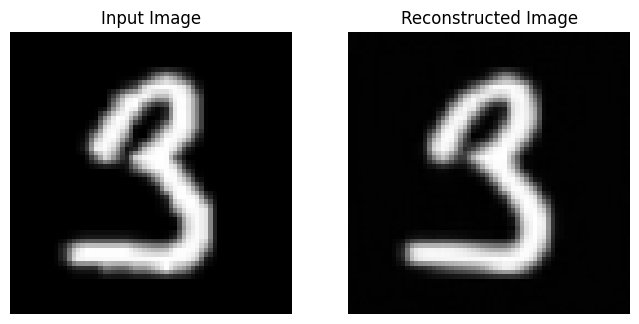

In [22]:
# Get one sample
data_loader1 = DataLoader(subset_data_set,batch_size=1,shuffle=True)
data_iter = iter(data_loader1)
img, label = next(data_iter)  # img shape: (1,1,64,64)
img=img.to(device)
# Pass through model
model.eval()
with torch.no_grad():
    output, _ = model(img)

# Prepare for plotting
input_img = img.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# De-normalize if needed (from [-1,1] back to [0,1])
input_img = (input_img * 0.5) + 0.5
output_img = (output_img * 0.5) + 0.5

# Plot side by side
plt.figure(figsize=(8,4))

# Input
plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Output
plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()

## (a) (20 points) Plot the t-sne (use inbuilt function) on the embeddings obtained using the respective auto-encoders. Color the clusters using the respective ground-truth class labels.

In [ ]:
model=ContractiveAutoEncoder(1)
model.load_state_dict(torch.load('Unet_Contractive_autoencoder.pkl'))
model.to(device)

<All keys matched successfully>

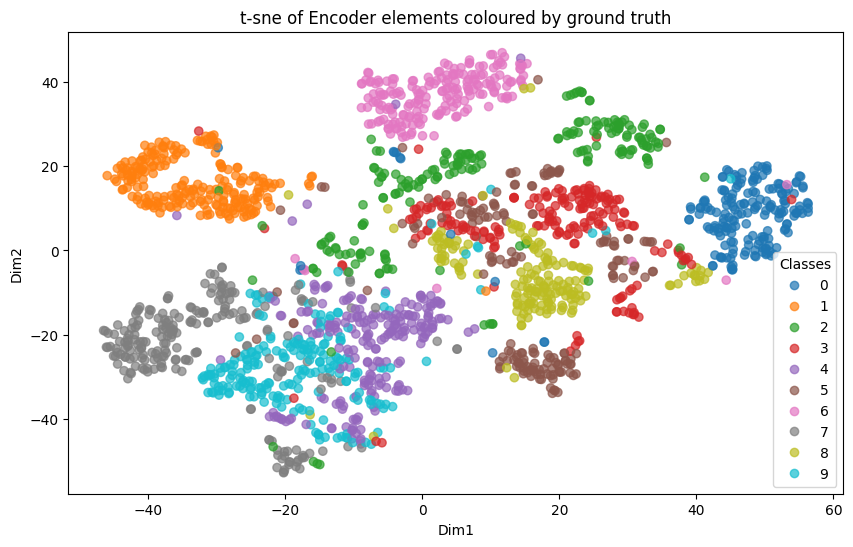

In [25]:
subset_indices=list(range(2000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_eval = DataLoader(subset_data_set,batch_size=100,shuffle=True)
embeddings= []
labels=[]

model.eval()
with torch.no_grad():
    for data,label in data_loader_eval:
        data=data.to(device)

        # encoder Embeddings
        encoder_embeddings=model.encoder(data)

        #Flatening the sample for t-sne
        encoder_embeddings_flattened=encoder_embeddings.view(encoder_embeddings.size(0),-1)

        embeddings.append(encoder_embeddings_flattened)
        labels.append(label)

#concatinate the embeddings and labels
embeddings=torch.cat(embeddings,dim=0)
labels=torch.cat(labels,dim=0)

#Apply t-sne
tsne= TSNE(n_components=2,random_state=42)
embeddings_in_2d=tsne.fit_transform(embeddings.detach().cpu().numpy())

#Plot
plt.figure(figsize=(10,6))
scatter=plt.scatter(embeddings_in_2d[:,0],embeddings_in_2d[:,1],c=labels,cmap='tab10',alpha=0.7)
plt.legend(*scatter.legend_elements(),title='Classes')
plt.title('t-sne of Encoder elements coloured by ground truth')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.show()

![image.png](attachment:image.png)

In [26]:
subset_indices=list(range(100))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q2 = DataLoader(subset_data_set,batch_size=2,shuffle=True)

In [27]:
def calculate_psnr(img1,img2,max_value=1):
    '''The images are tensors of same dimension with values [0,1]'''
    mse=torch.mean((img1-img2)**2)
    if mse==0:
        return float('inf')
    else:
        psnr_value=20*torch.log10(max_value/mse)
    return psnr_value
def l2norm(img1,img2):
    l2diff=torch.norm(img1-img2,p=2)
    return l2diff


--------------------------------> For the image Pair 1 <--------------------------------



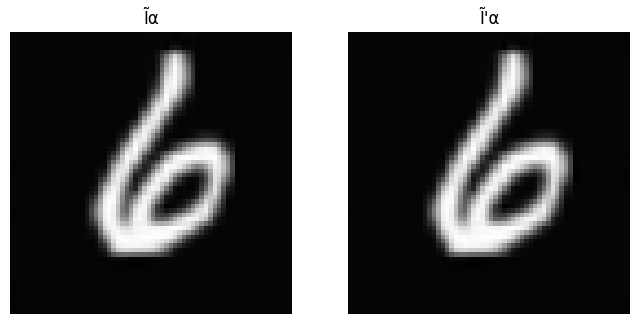

PSNR Value inf ----- L2 value 0.0


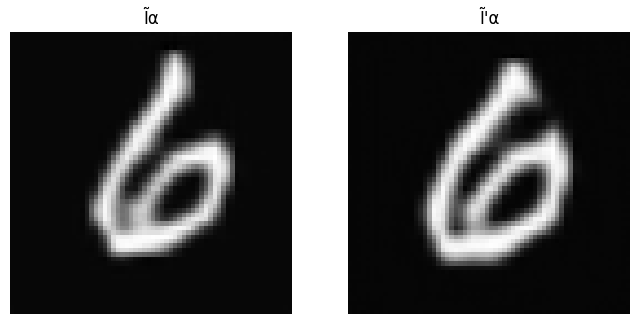

PSNR Value 26.439308166503906 ----- L2 value 13.970026969909668


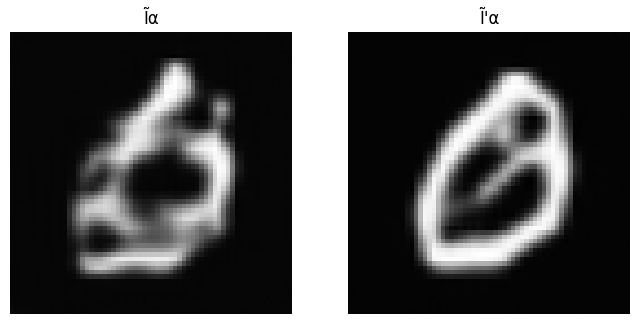

PSNR Value 18.326520919799805 ----- L2 value 22.28522300720215


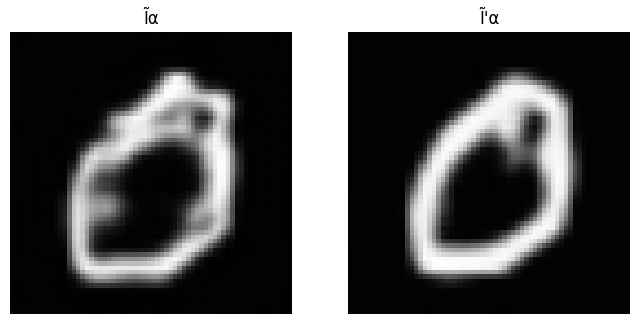

PSNR Value 22.50481605529785 ----- L2 value 17.521028518676758


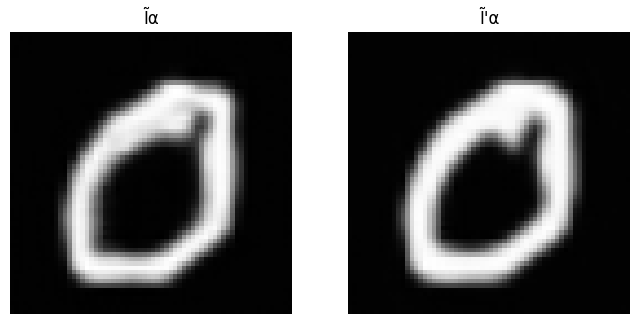

PSNR Value 34.94133377075195 ----- L2 value 8.563409805297852


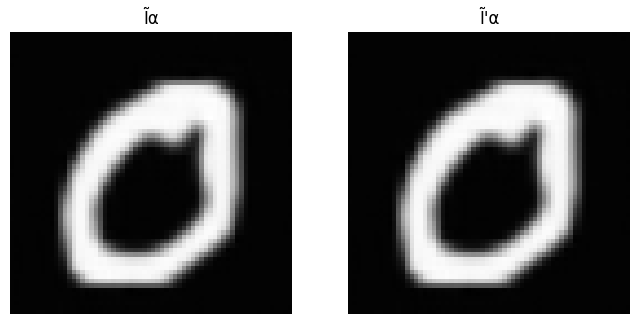

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 2 <--------------------------------



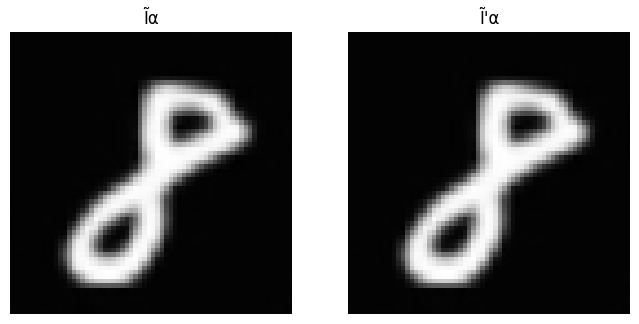

PSNR Value inf ----- L2 value 0.0


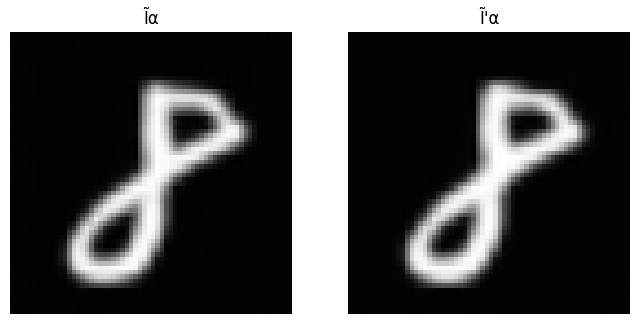

PSNR Value 52.18191146850586 ----- L2 value 3.1741855144500732


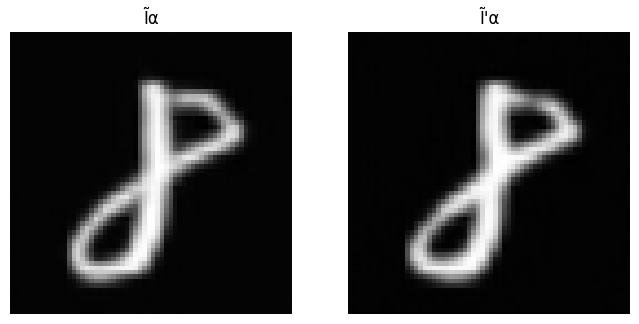

PSNR Value 38.0284309387207 ----- L2 value 7.16917610168457


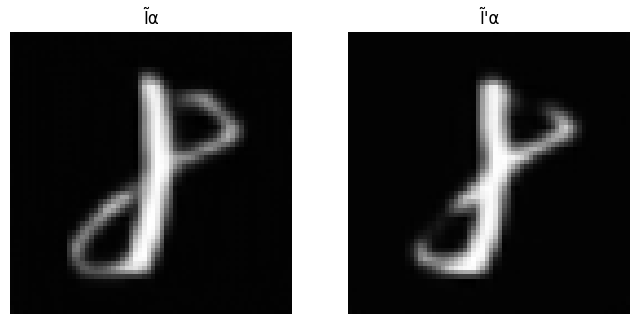

PSNR Value 32.3429069519043 ----- L2 value 9.945058822631836


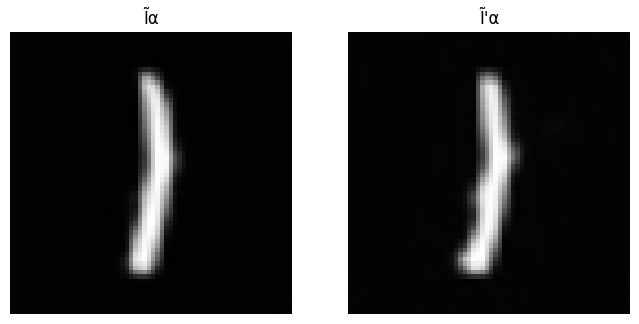

PSNR Value 48.037994384765625 ----- L2 value 4.029304504394531


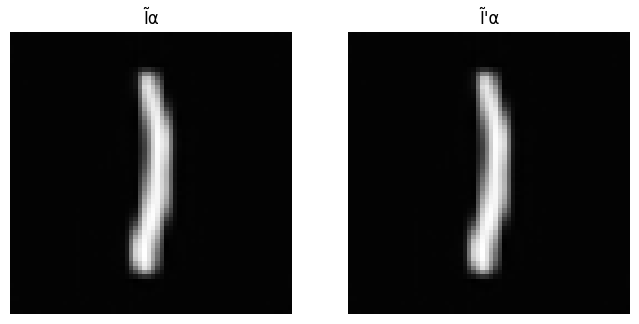

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 3 <--------------------------------



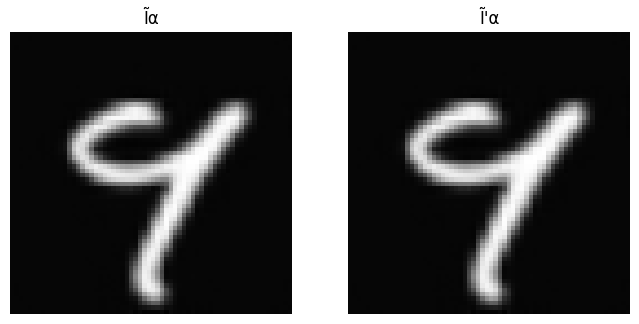

PSNR Value inf ----- L2 value 0.0


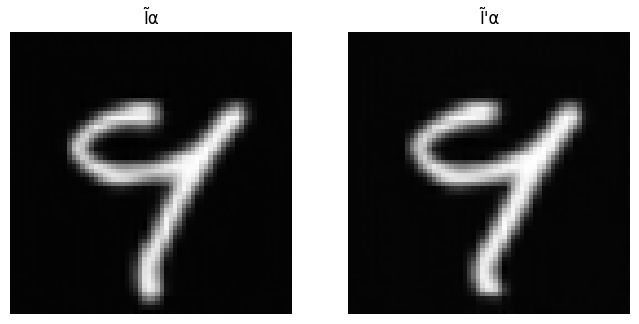

PSNR Value 44.3466796875 ----- L2 value 4.983253002166748


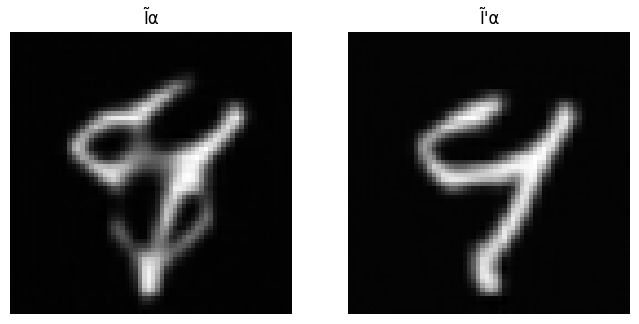

PSNR Value 24.53657341003418 ----- L2 value 15.587112426757812


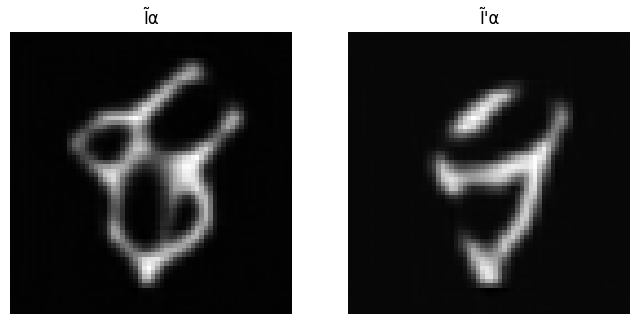

PSNR Value 23.223360061645508 ----- L2 value 16.81109619140625


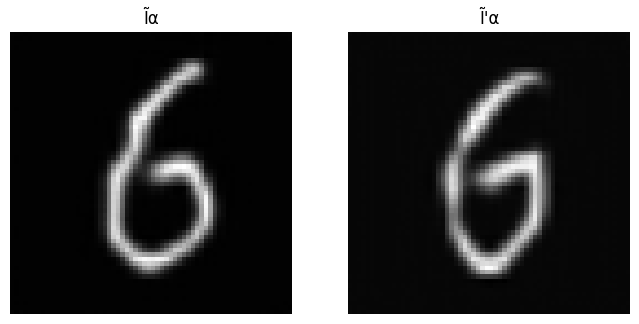

PSNR Value 29.959609985351562 ----- L2 value 11.40748119354248


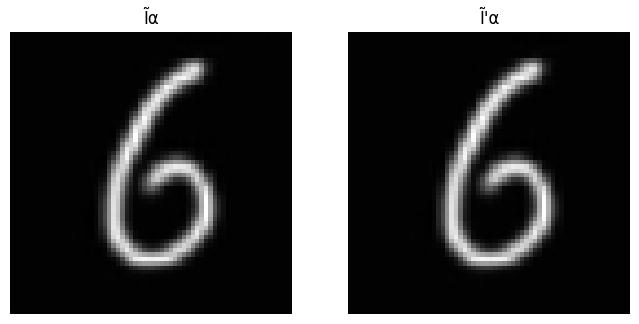

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 4 <--------------------------------



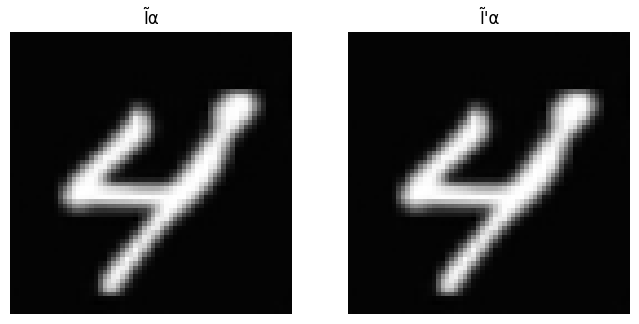

PSNR Value inf ----- L2 value 0.0


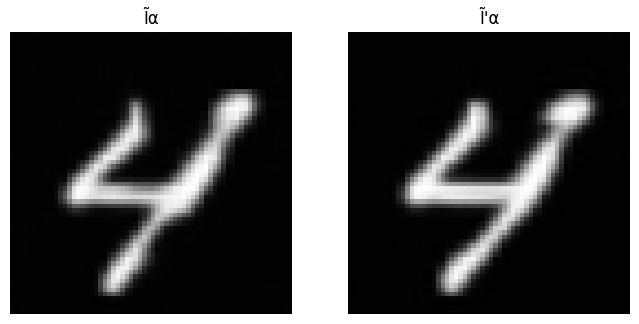

PSNR Value 34.342323303222656 ----- L2 value 8.86384105682373


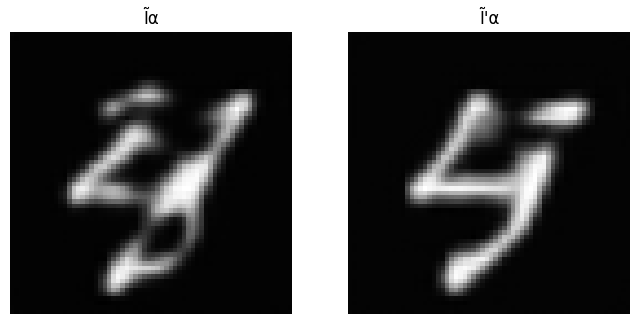

PSNR Value 21.978221893310547 ----- L2 value 18.060279846191406


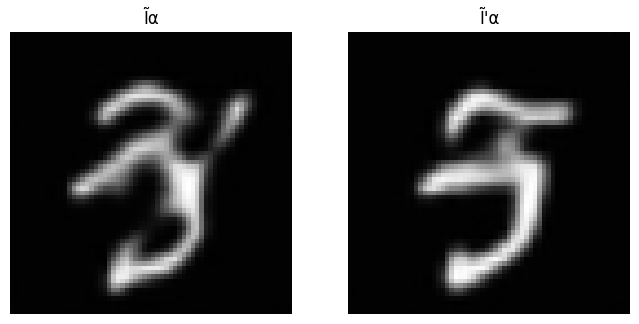

PSNR Value 20.733339309692383 ----- L2 value 19.40199851989746


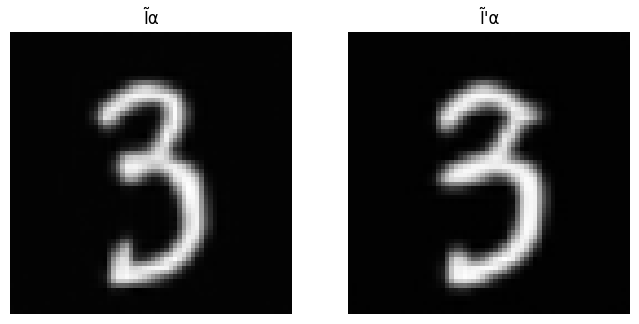

PSNR Value 32.222999572753906 ----- L2 value 10.01393985748291


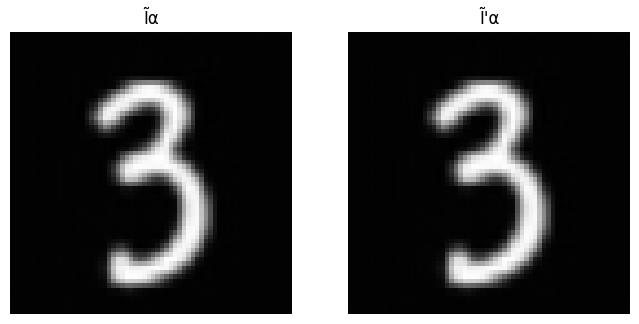

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 5 <--------------------------------



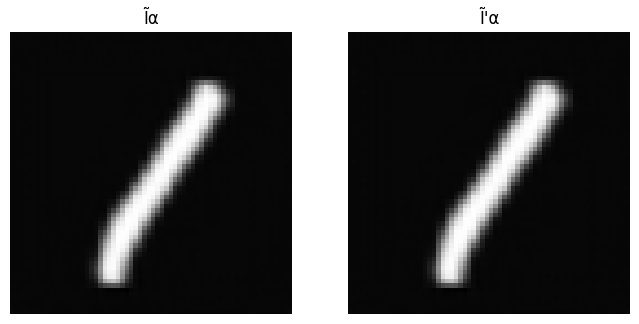

PSNR Value inf ----- L2 value 0.0


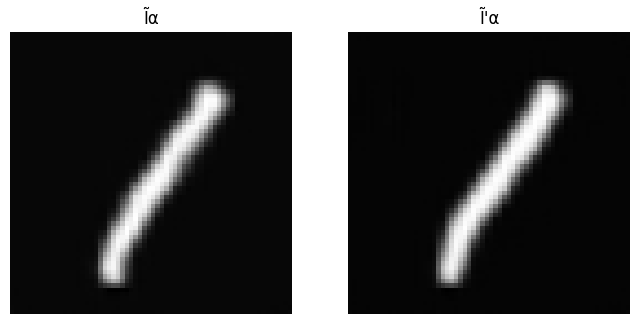

PSNR Value 48.742794036865234 ----- L2 value 3.8691020011901855


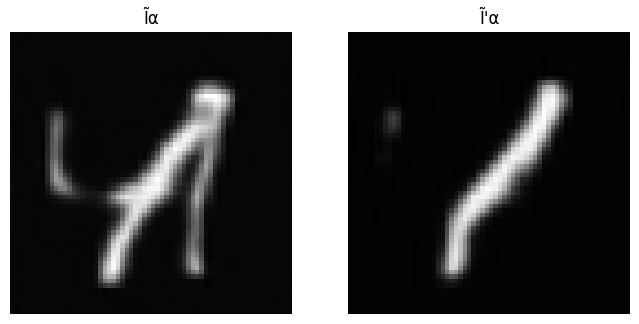

PSNR Value 27.869691848754883 ----- L2 value 12.865825653076172


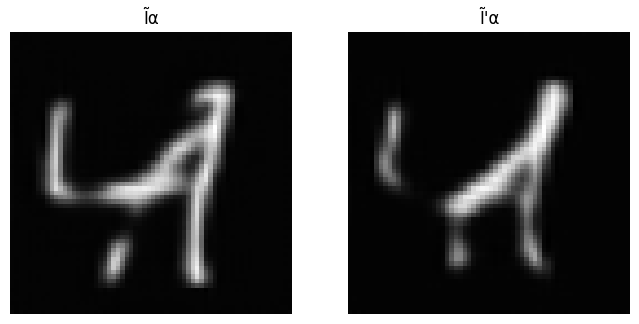

PSNR Value 25.293882369995117 ----- L2 value 14.922203063964844


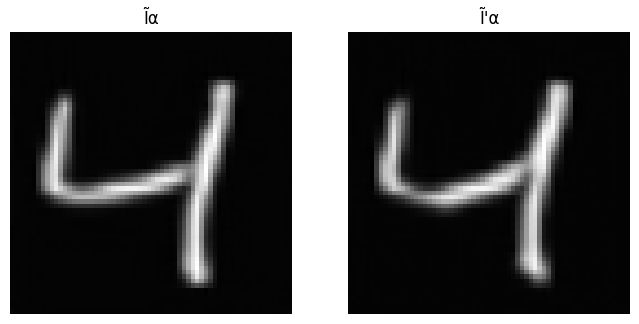

PSNR Value 35.16706848144531 ----- L2 value 8.452852249145508


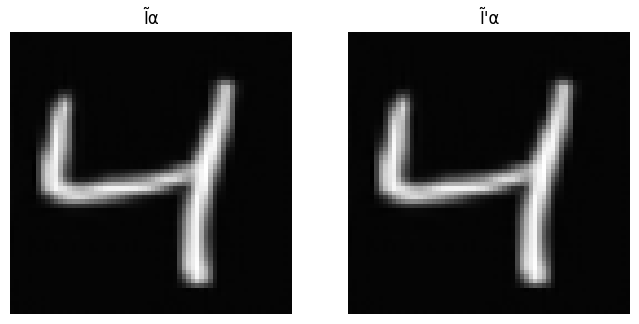

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 6 <--------------------------------



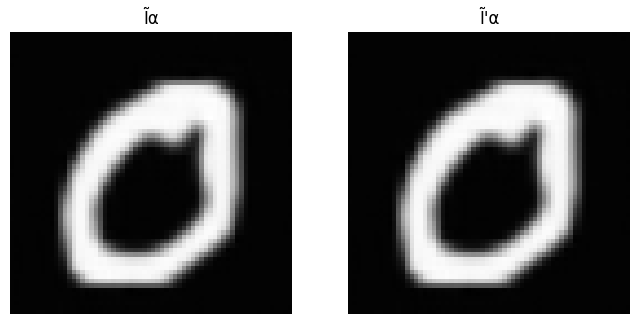

PSNR Value inf ----- L2 value 0.0


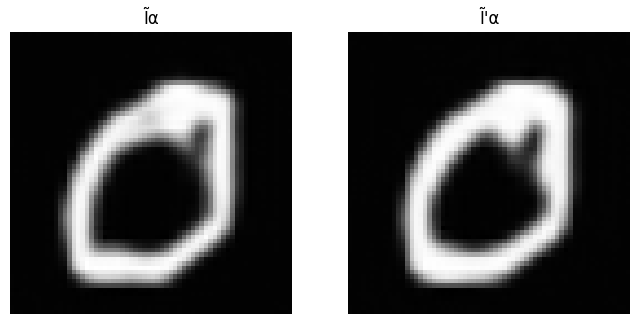

PSNR Value 36.09188461303711 ----- L2 value 8.014619827270508


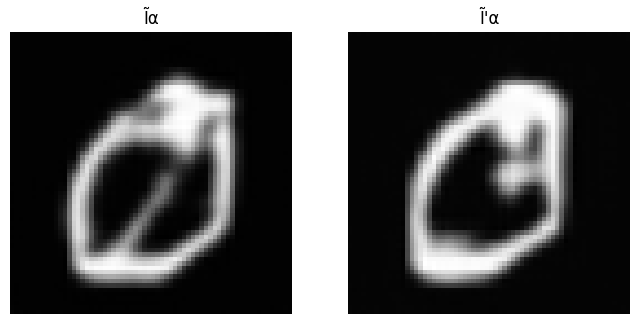

PSNR Value 21.409740447998047 ----- L2 value 18.66106605529785


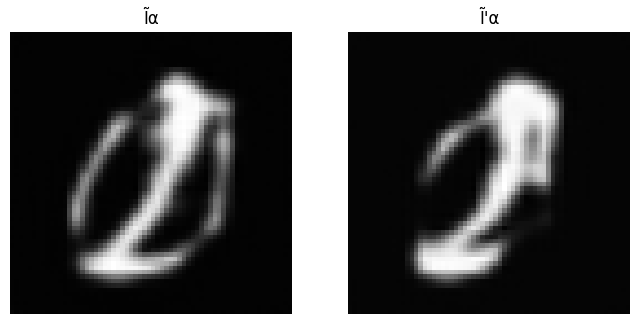

PSNR Value 22.27845001220703 ----- L2 value 17.750831604003906


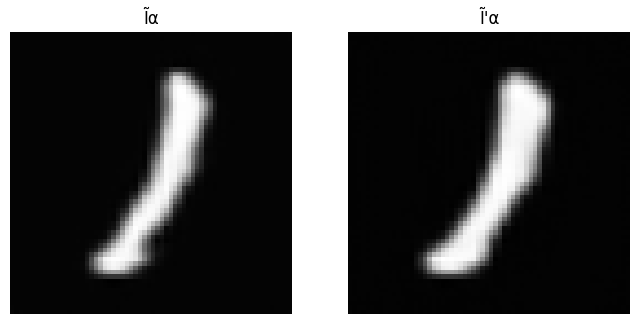

PSNR Value 37.559593200683594 ----- L2 value 7.365295886993408


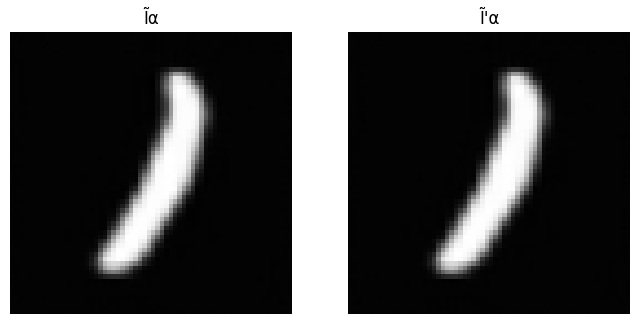

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 7 <--------------------------------



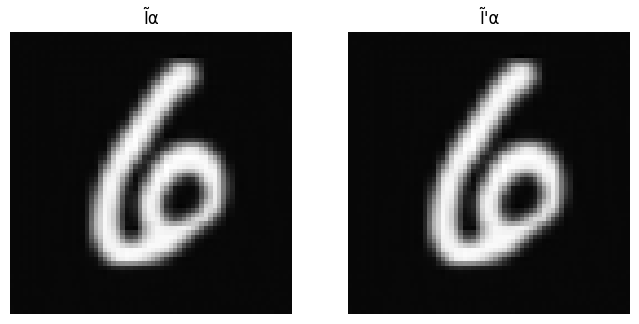

PSNR Value inf ----- L2 value 0.0


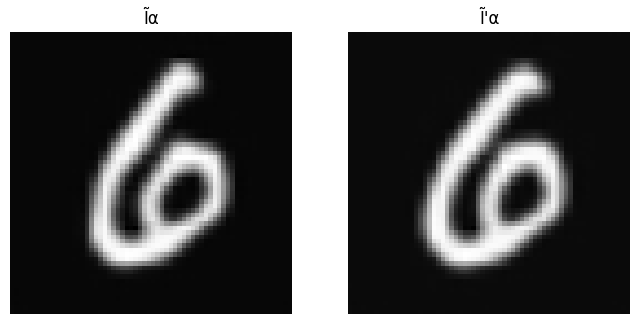

PSNR Value 40.504600524902344 ----- L2 value 6.216772556304932


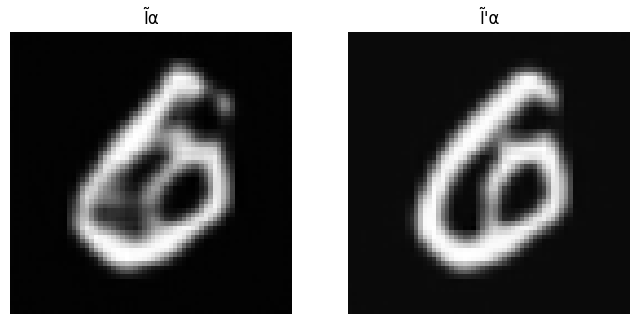

PSNR Value 30.182647705078125 ----- L2 value 11.261955261230469


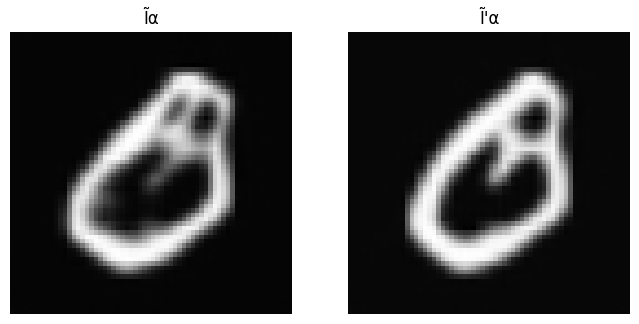

PSNR Value 30.33295440673828 ----- L2 value 11.164933204650879


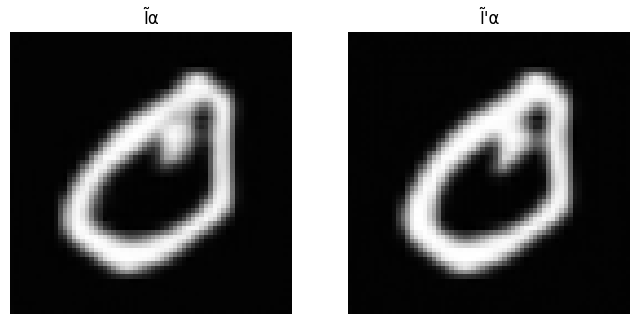

PSNR Value 41.192325592041016 ----- L2 value 5.975466251373291


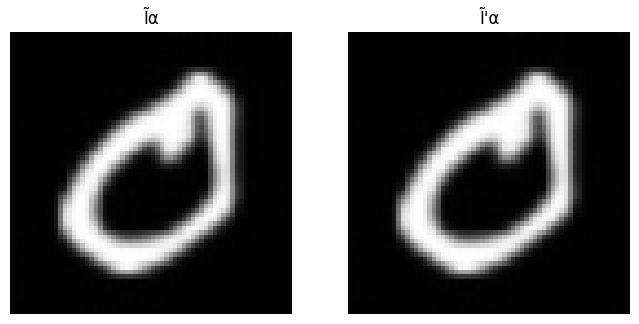

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 8 <--------------------------------



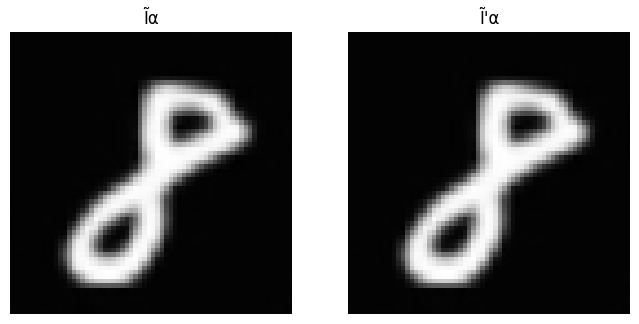

PSNR Value inf ----- L2 value 0.0


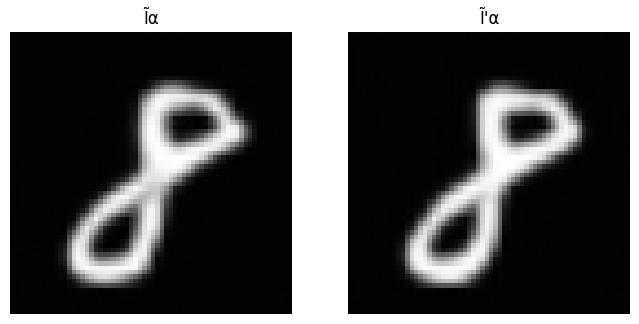

PSNR Value 45.99014663696289 ----- L2 value 4.533423900604248


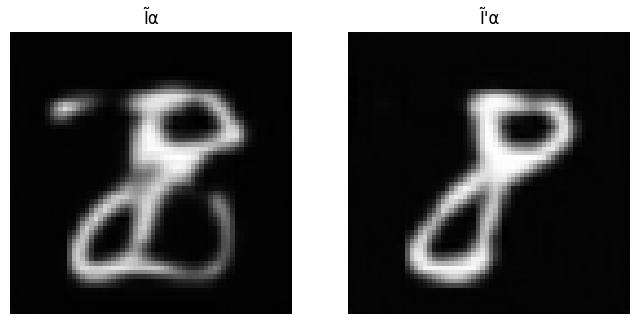

PSNR Value 24.46733856201172 ----- L2 value 15.649356842041016


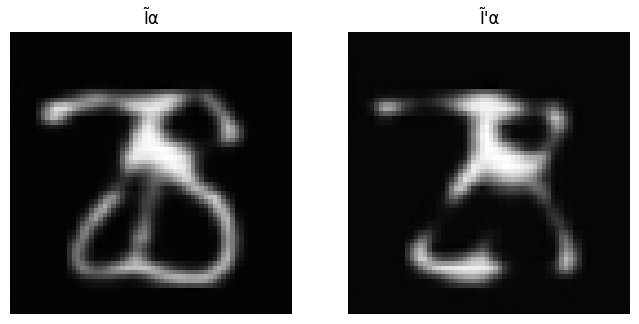

PSNR Value 22.019968032836914 ----- L2 value 18.016929626464844


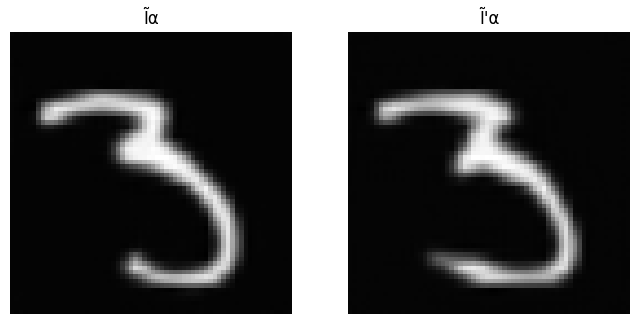

PSNR Value 34.74032974243164 ----- L2 value 8.663068771362305


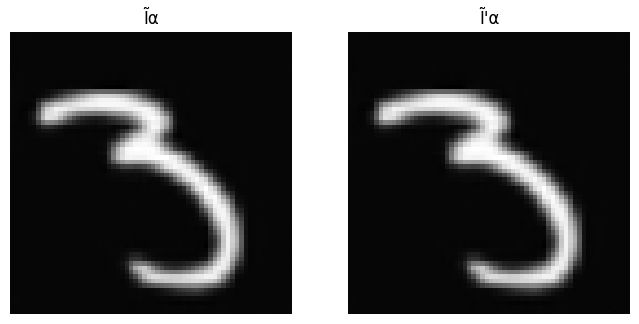

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 9 <--------------------------------



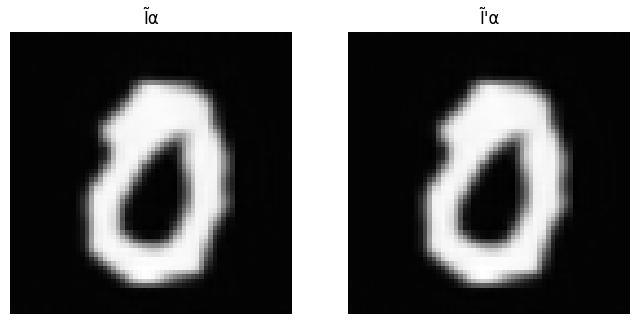

PSNR Value inf ----- L2 value 0.0


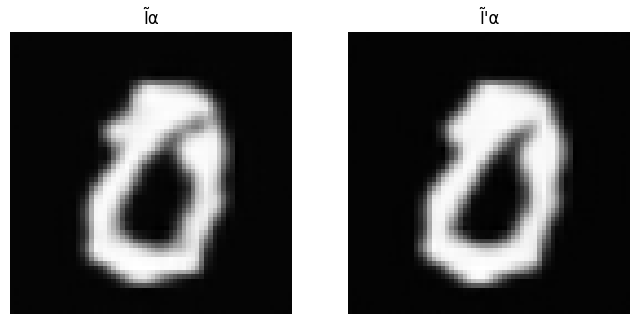

PSNR Value 40.257362365722656 ----- L2 value 6.305882930755615


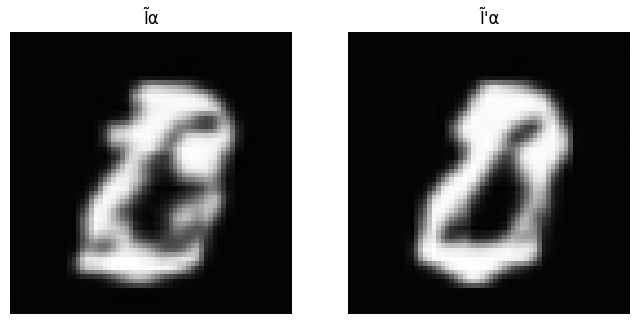

PSNR Value 25.72589683532715 ----- L2 value 14.555682182312012


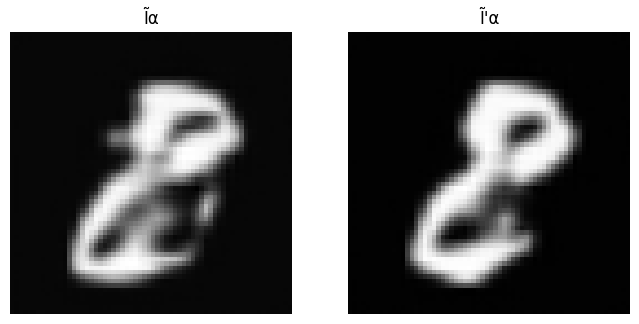

PSNR Value 26.02081298828125 ----- L2 value 14.310661315917969


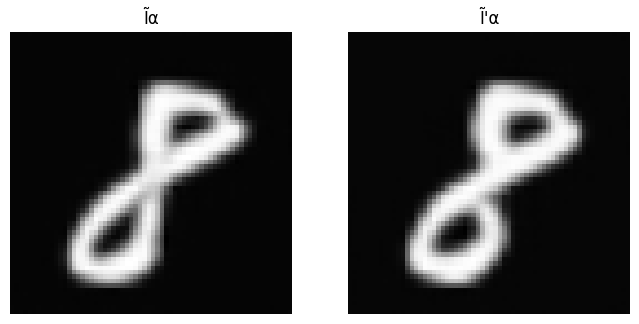

PSNR Value 36.50703048706055 ----- L2 value 7.825357437133789


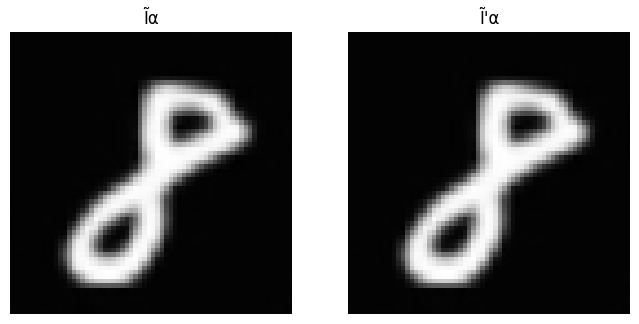

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 10 <--------------------------------



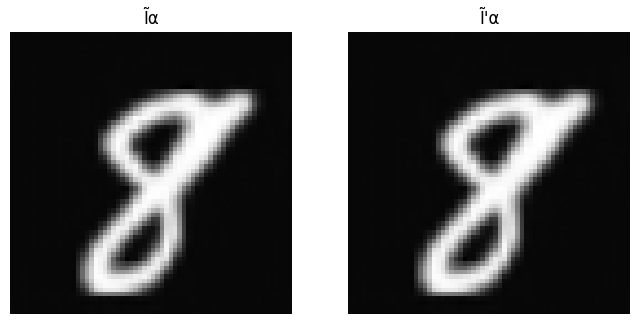

PSNR Value inf ----- L2 value 0.0


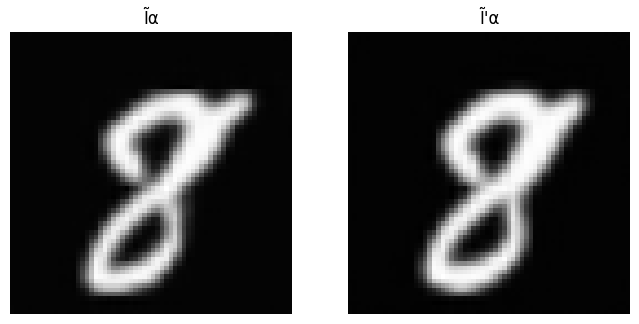

PSNR Value 37.65327072143555 ----- L2 value 7.325685024261475


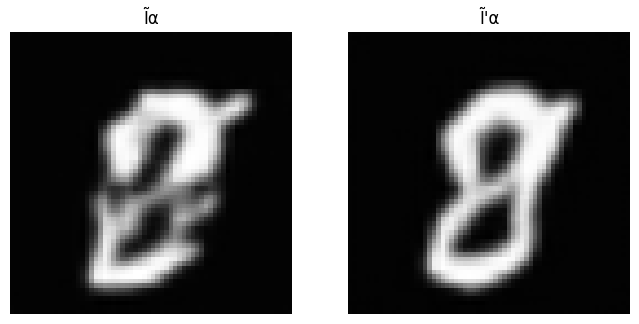

PSNR Value 27.1998233795166 ----- L2 value 13.37163257598877


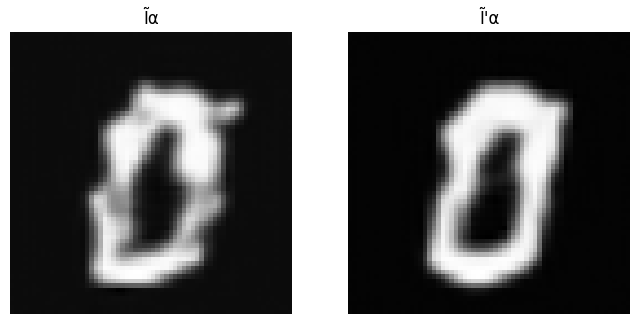

PSNR Value 29.255102157592773 ----- L2 value 11.879617691040039


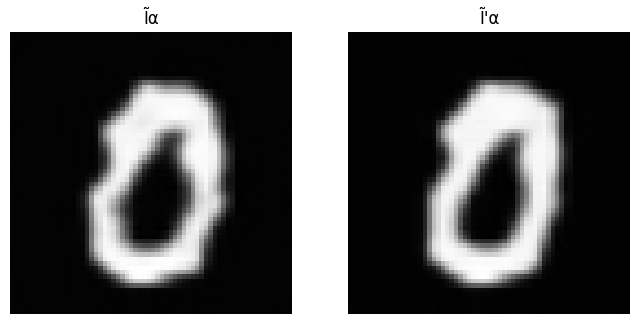

PSNR Value 41.23998260498047 ----- L2 value 5.959097862243652


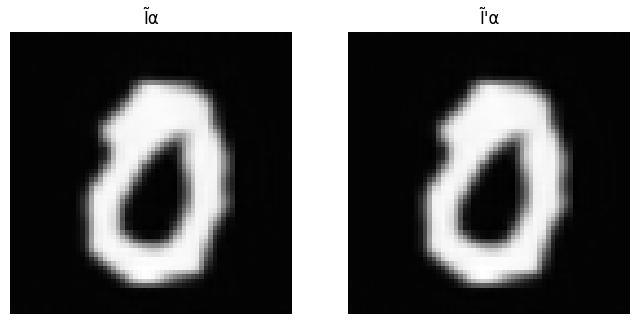

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 11 <--------------------------------



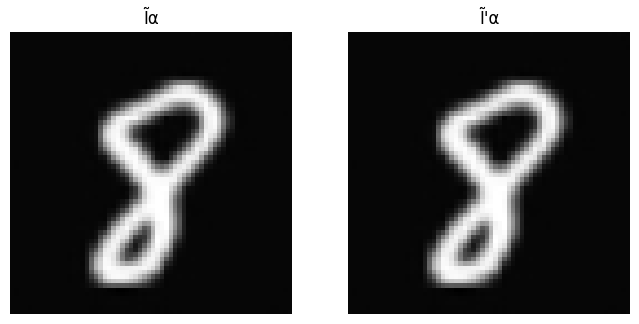

PSNR Value inf ----- L2 value 0.0


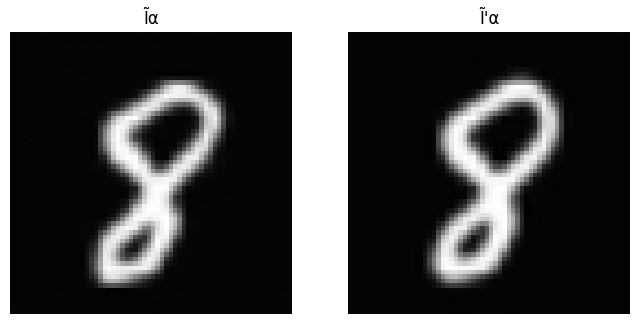

PSNR Value 42.72334671020508 ----- L2 value 5.471373081207275


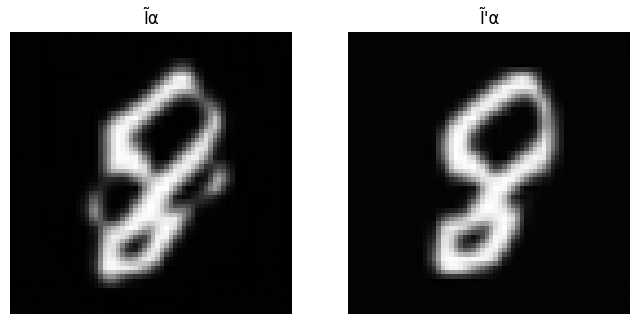

PSNR Value 31.48967933654785 ----- L2 value 10.445710182189941


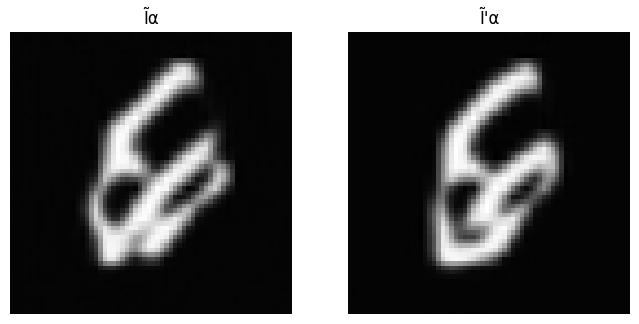

PSNR Value 30.555532455444336 ----- L2 value 11.02279281616211


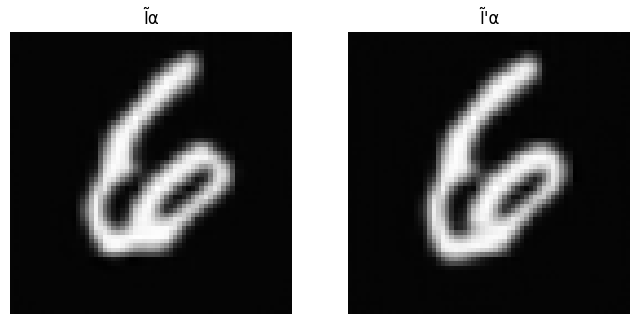

PSNR Value 39.028953552246094 ----- L2 value 6.767934322357178


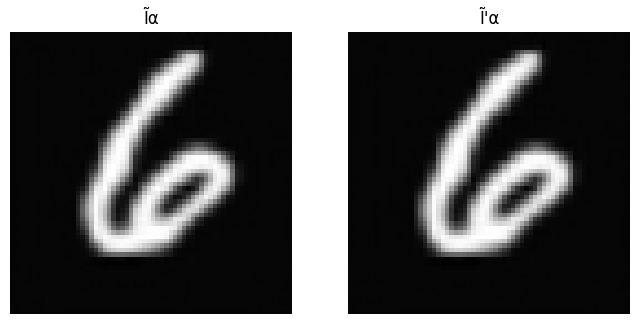

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 12 <--------------------------------



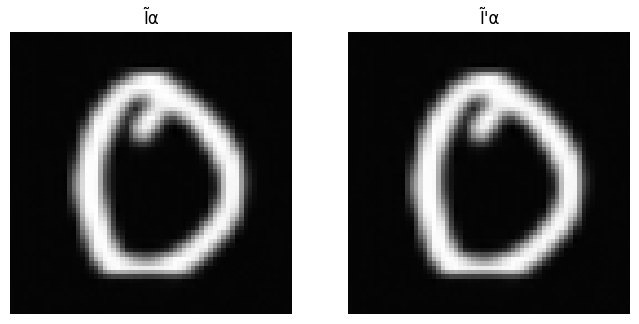

PSNR Value inf ----- L2 value 0.0


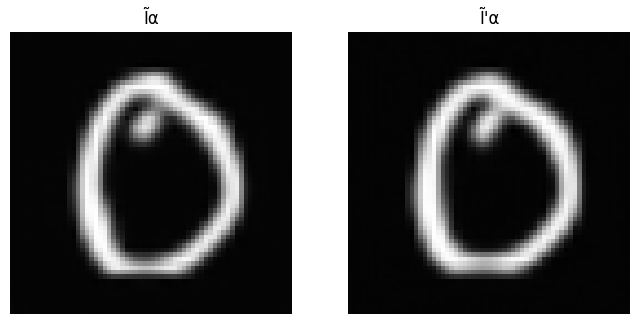

PSNR Value 40.8683967590332 ----- L2 value 6.087935447692871


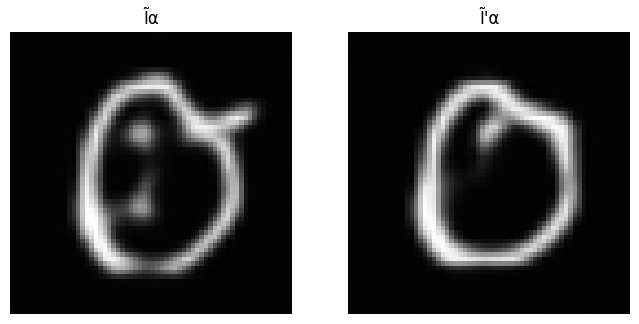

PSNR Value 23.714845657348633 ----- L2 value 16.342138290405273


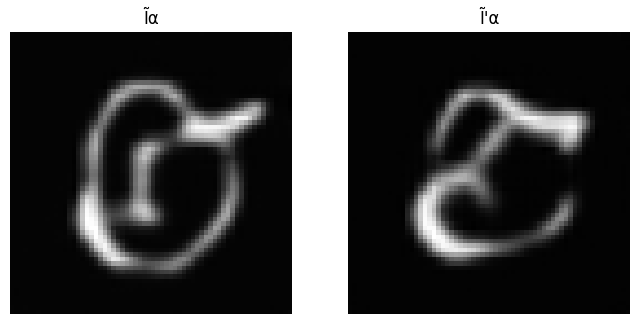

PSNR Value 21.854467391967773 ----- L2 value 18.189395904541016


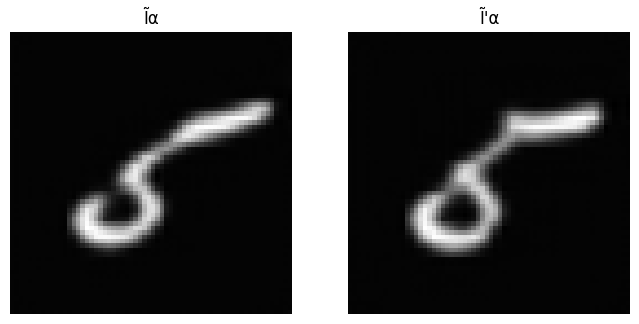

PSNR Value 33.794776916503906 ----- L2 value 9.147671699523926


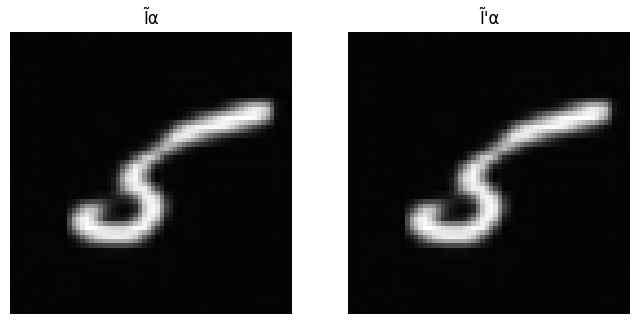

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 13 <--------------------------------



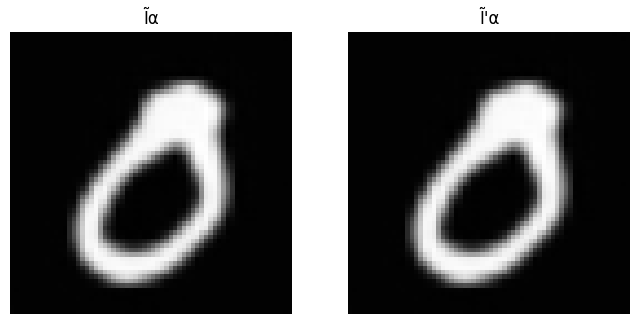

PSNR Value inf ----- L2 value 0.0


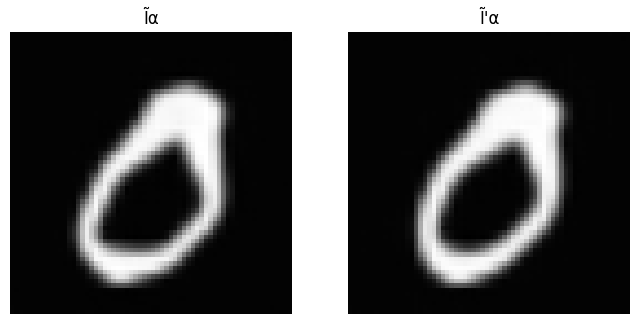

PSNR Value 41.296958923339844 ----- L2 value 5.939583778381348


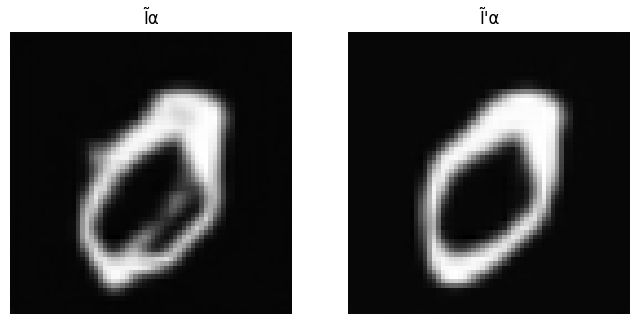

PSNR Value 28.040742874145508 ----- L2 value 12.739765167236328


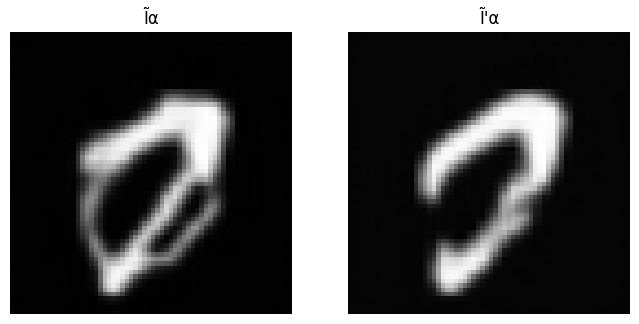

PSNR Value 27.904245376586914 ----- L2 value 12.84026050567627


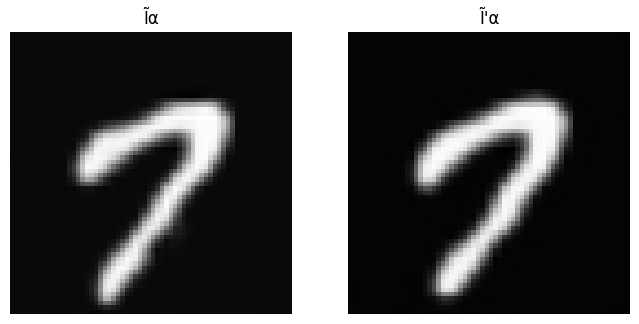

PSNR Value 40.26507568359375 ----- L2 value 6.3030853271484375


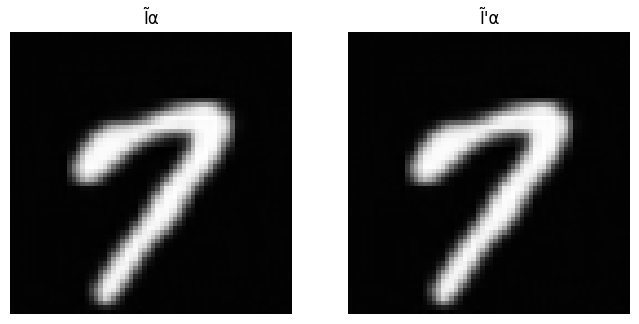

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 14 <--------------------------------



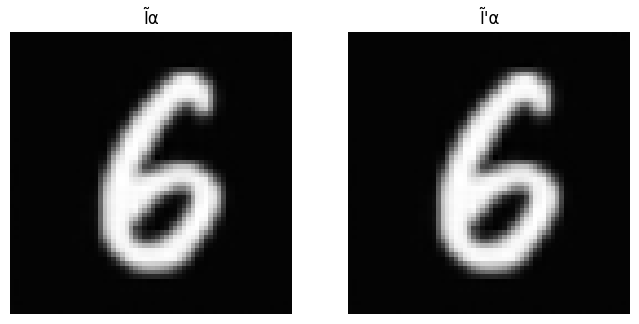

PSNR Value inf ----- L2 value 0.0


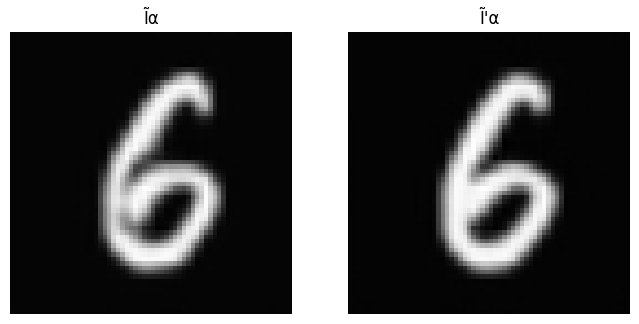

PSNR Value 41.651756286621094 ----- L2 value 5.819506645202637


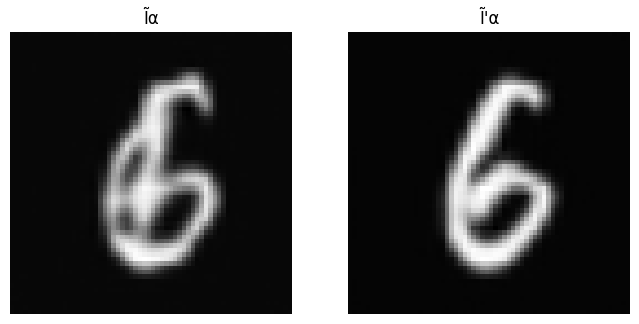

PSNR Value 26.756816864013672 ----- L2 value 13.71701431274414


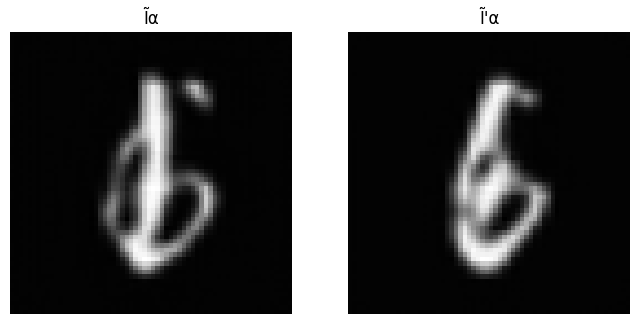

PSNR Value 24.478580474853516 ----- L2 value 15.63923454284668


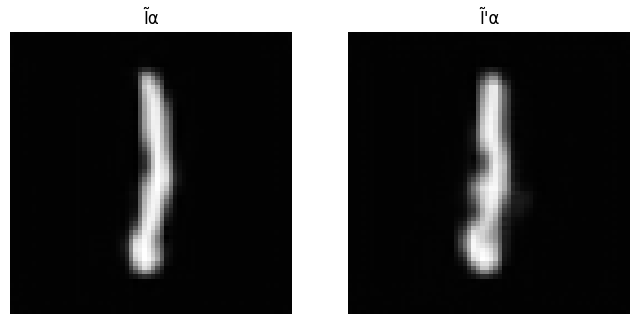

PSNR Value 42.433589935302734 ----- L2 value 5.563399791717529


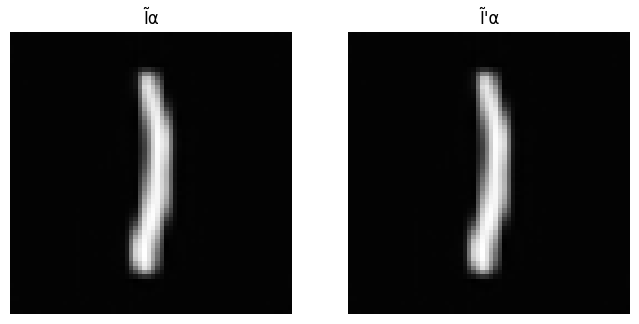

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 15 <--------------------------------



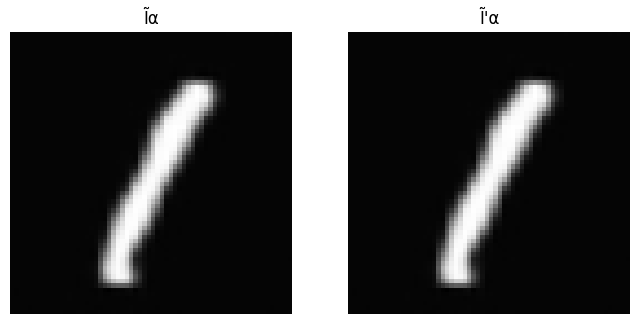

PSNR Value inf ----- L2 value 0.0


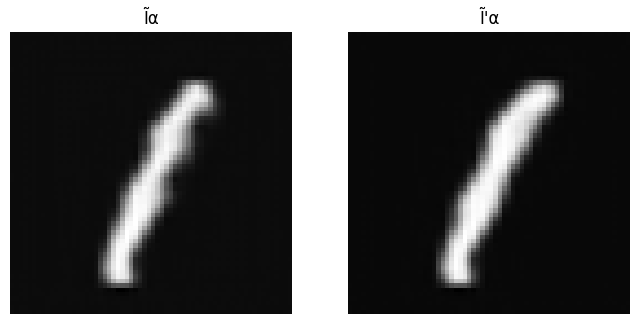

PSNR Value 41.38890838623047 ----- L2 value 5.908229351043701


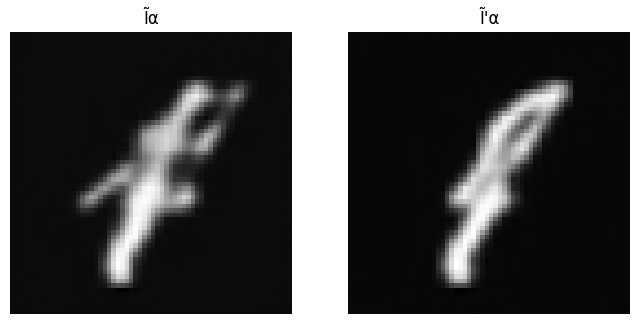

PSNR Value 26.30518341064453 ----- L2 value 14.078306198120117


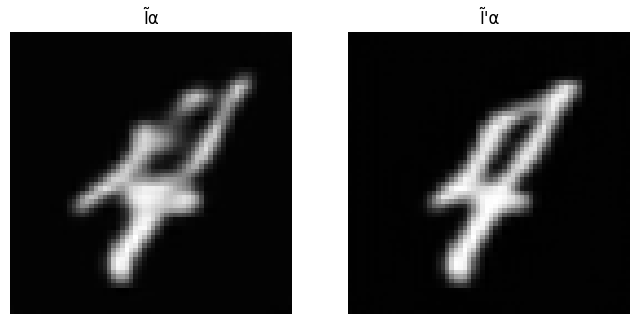

PSNR Value 24.241458892822266 ----- L2 value 15.854169845581055


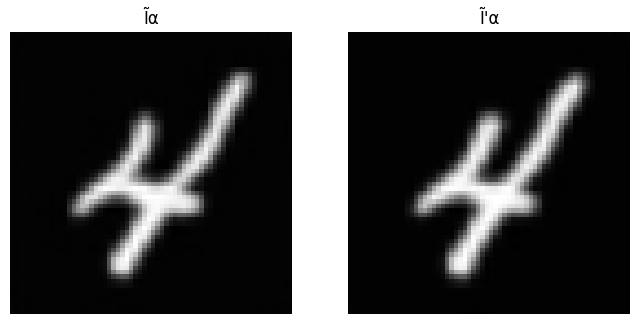

PSNR Value 35.82575988769531 ----- L2 value 8.138344764709473


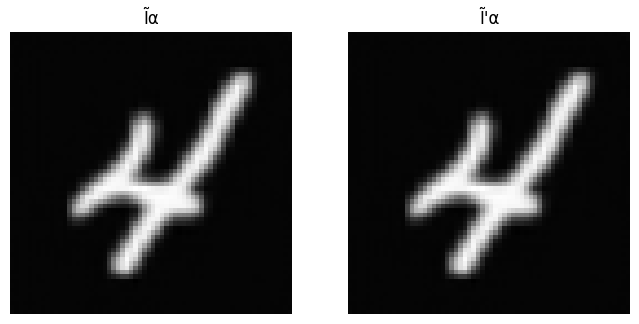

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 16 <--------------------------------



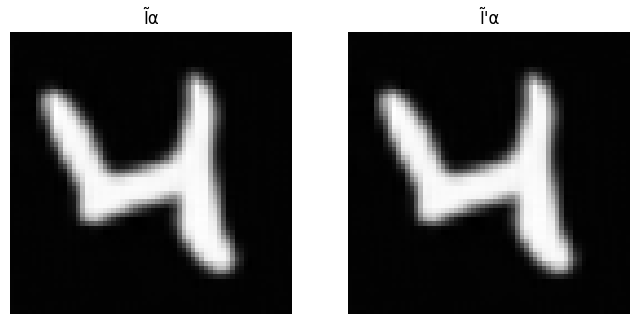

PSNR Value inf ----- L2 value 0.0


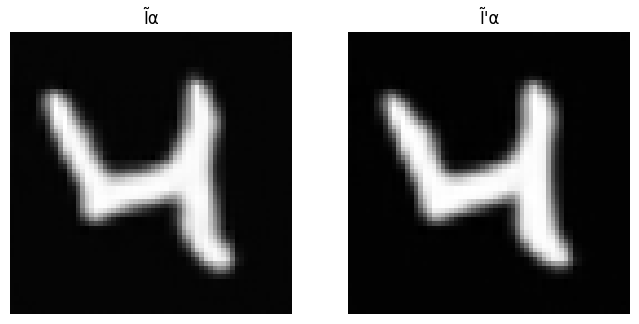

PSNR Value 45.06462478637695 ----- L2 value 4.7815022468566895


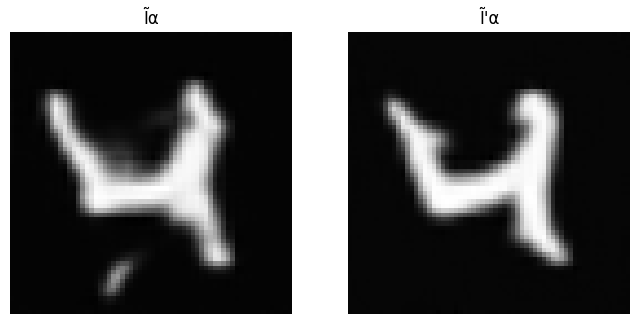

PSNR Value 27.068477630615234 ----- L2 value 13.473116874694824


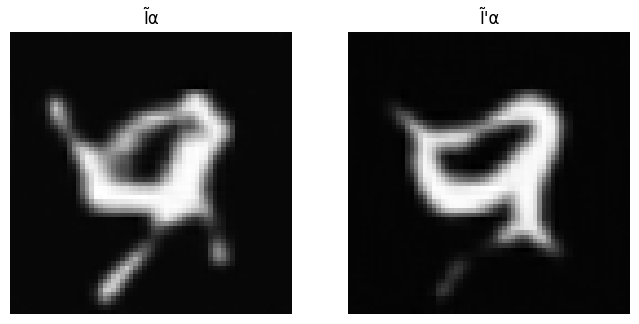

PSNR Value 21.70126724243164 ----- L2 value 18.35051727294922


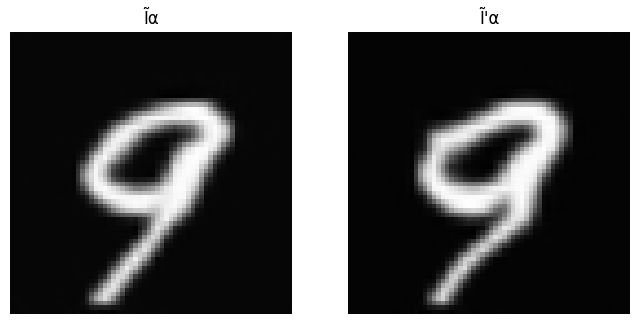

PSNR Value 32.822547912597656 ----- L2 value 9.674227714538574


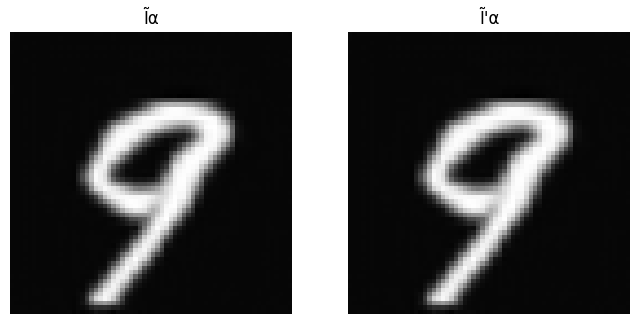

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 17 <--------------------------------



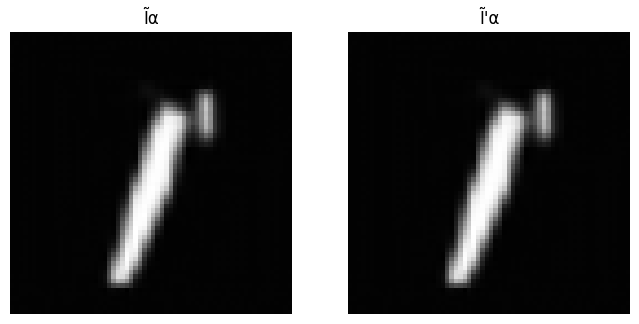

PSNR Value inf ----- L2 value 0.0


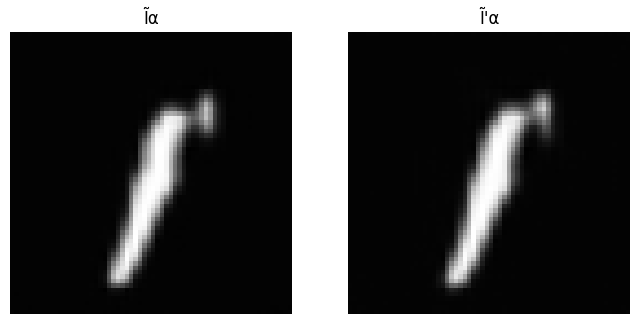

PSNR Value 56.446571350097656 ----- L2 value 2.4832231998443604


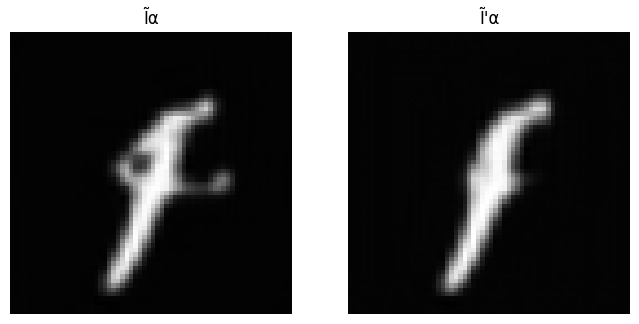

PSNR Value 39.24437713623047 ----- L2 value 6.684525966644287


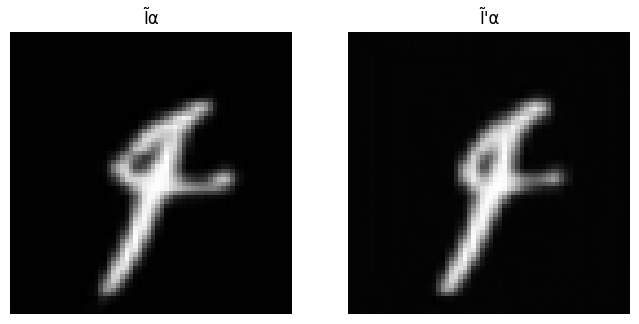

PSNR Value 40.116668701171875 ----- L2 value 6.357162952423096


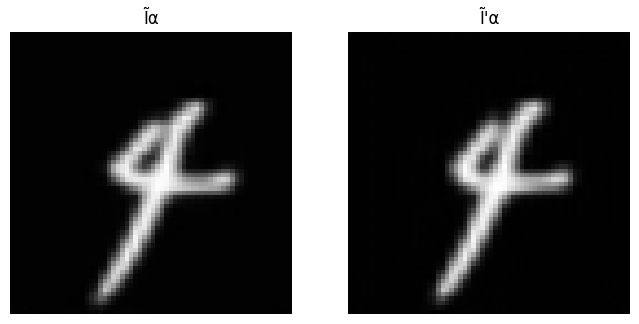

PSNR Value 52.23955154418945 ----- L2 value 3.163670778274536


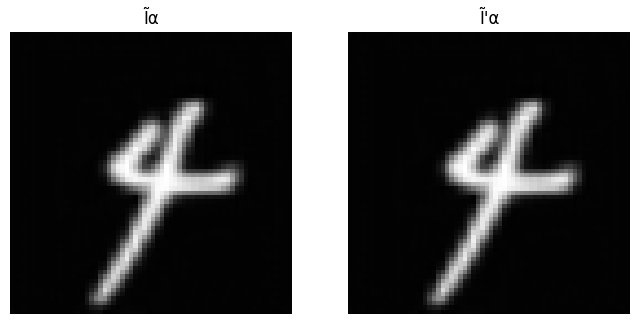

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 18 <--------------------------------



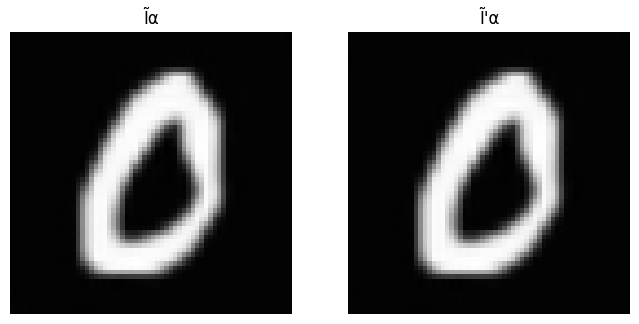

PSNR Value inf ----- L2 value 0.0


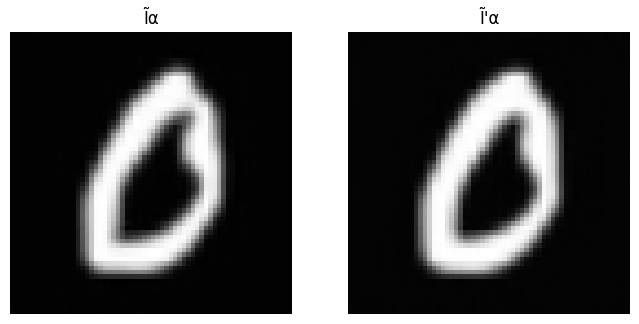

PSNR Value 49.119956970214844 ----- L2 value 3.7860031127929688


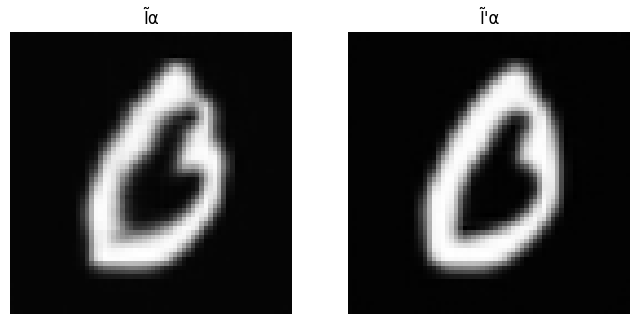

PSNR Value 40.01513671875 ----- L2 value 6.394426345825195


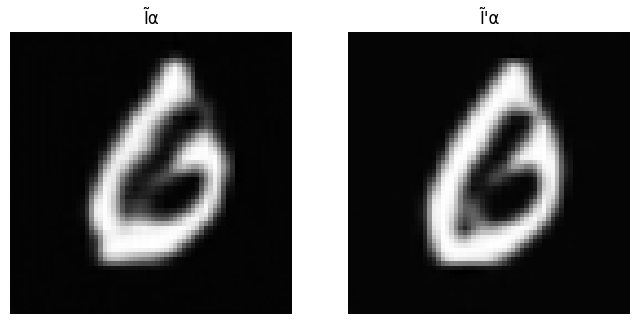

PSNR Value 33.09749984741211 ----- L2 value 9.52231502532959


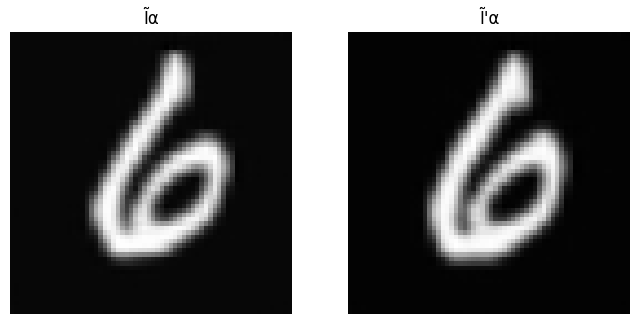

PSNR Value 38.28428268432617 ----- L2 value 7.064362049102783


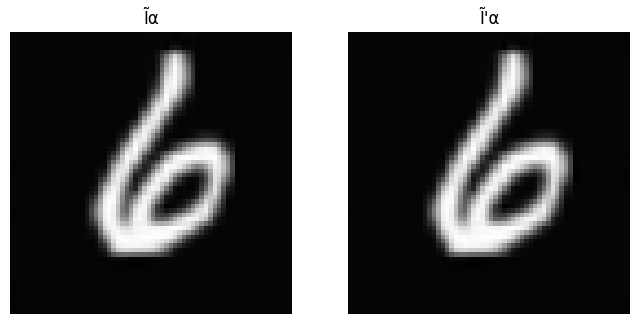

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 19 <--------------------------------



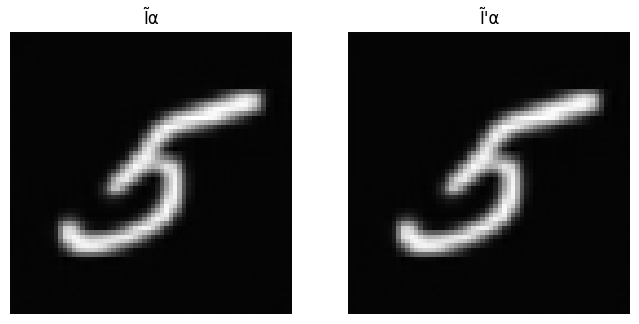

PSNR Value inf ----- L2 value 0.0


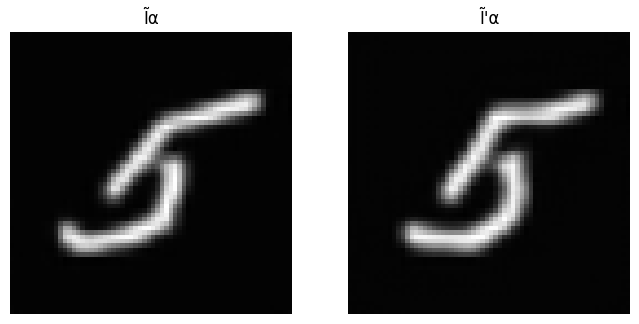

PSNR Value 29.690580368041992 ----- L2 value 11.585518836975098


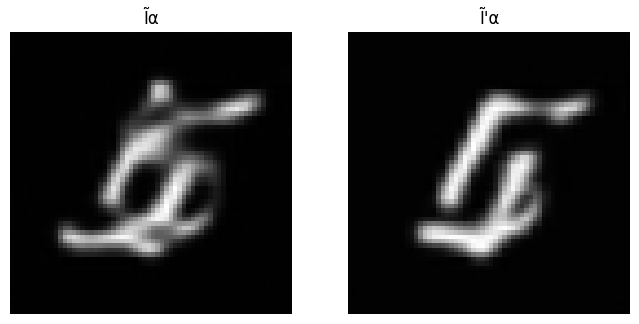

PSNR Value 24.47417449951172 ----- L2 value 15.643199920654297


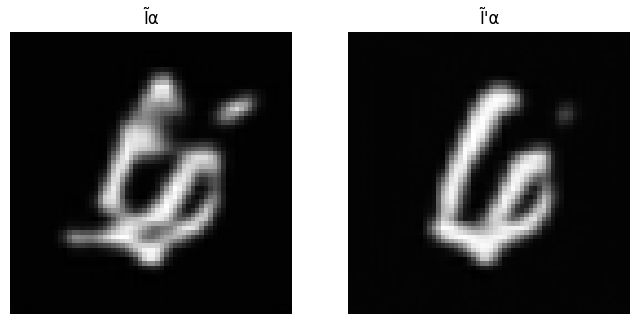

PSNR Value 26.91922378540039 ----- L2 value 13.589371681213379


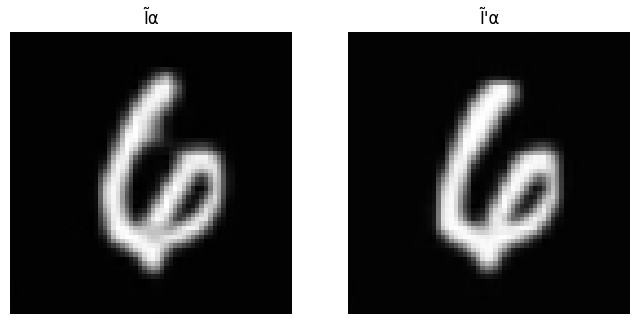

PSNR Value 41.67774963378906 ----- L2 value 5.810803413391113


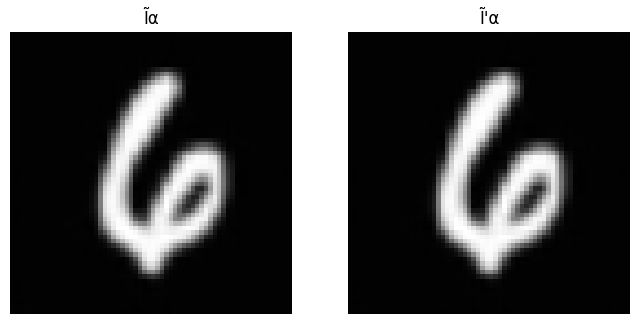

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 20 <--------------------------------



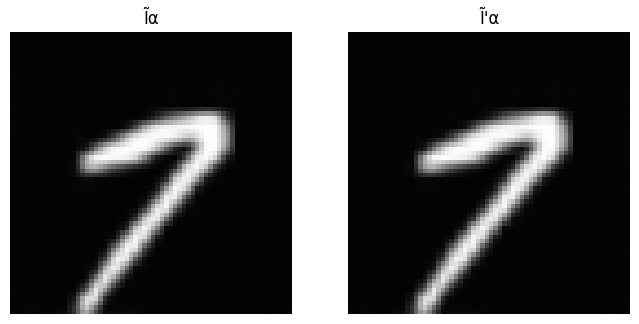

PSNR Value inf ----- L2 value 0.0


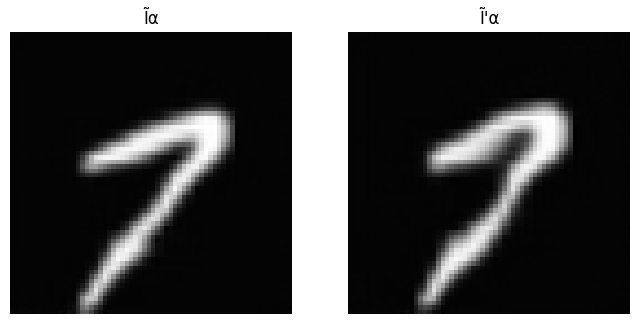

PSNR Value 34.608211517333984 ----- L2 value 8.729205131530762


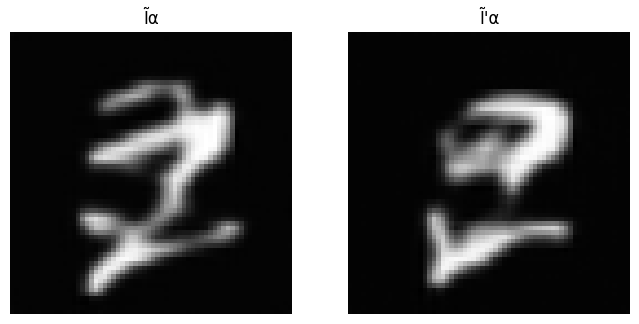

PSNR Value 19.277421951293945 ----- L2 value 21.09815216064453


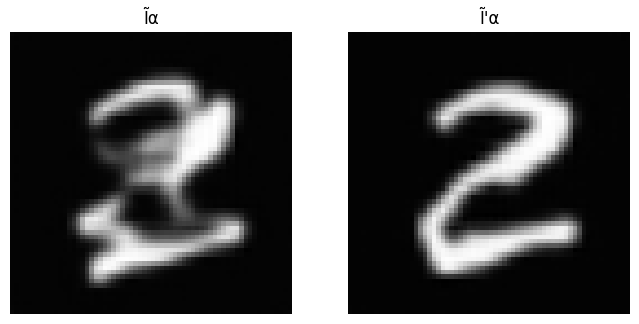

PSNR Value 21.01278305053711 ----- L2 value 19.092395782470703


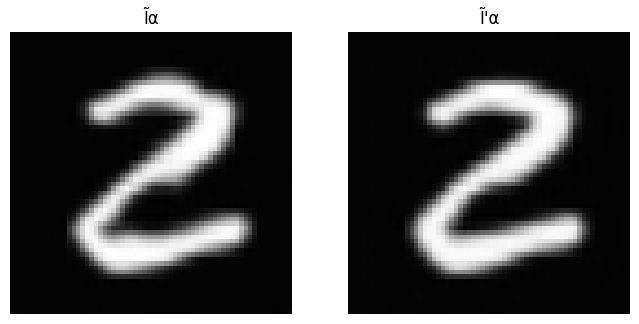

PSNR Value 38.96165466308594 ----- L2 value 6.794204235076904


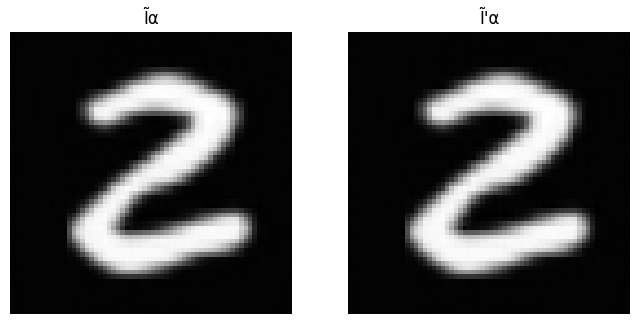

PSNR Value inf ----- L2 value 0.0


In [29]:
alphas=[0, 0.2, 0.4, 0.6, 0.8, 1.]
for i in range(1,21):
    for featues, labels in data_loader_q2:
        if labels[0]!=labels[1]:
            break
        else:
            pass
    print(f'\n--------------------------------> For the image Pair {i} <--------------------------------\n')
    for alpha in alphas:
        I1=featues[0]
        I2=featues[1]
        I2=I2.to(device)
        I1=I1.to(device)
        I_alpha=alpha*I1+(1-alpha)*I2

        model.eval()
        with torch.no_grad():
            # encoder Embeddings
            h_alpha=model.encoder(I_alpha)
            h1=model.encoder(I1)
            h2=model.encoder(I2)

            h_dash_alpha=alpha*h1+(1-alpha)*h2

            h_alpha_bottle_neck=model.bottleneck(h_alpha)
            h_dash_alpha_bottle_neck=model.bottleneck(h_dash_alpha)

            i_alpha_hat=model.decoder(h_alpha_bottle_neck)
            i_dash_alpha_hat=model.decoder(h_dash_alpha_bottle_neck)

            psnr=calculate_psnr(i_alpha_hat,i_dash_alpha_hat)
            l2=l2norm(i_alpha_hat,i_dash_alpha_hat)

            # Prepare for plotting
            i_alpha_hat_img = i_alpha_hat.squeeze().cpu().numpy()
            i_dash_alpha__img = i_dash_alpha_hat.squeeze().cpu().numpy()

            # De-normalize if needed (from [-1,1] back to [0,1])
            i_alpha_hat_img = (i_alpha_hat_img * 0.5) + 0.5
            i_dash_alpha__img = (i_dash_alpha__img * 0.5) + 0.5

            # Plot side by side
            plt.figure(figsize=(8,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(i_alpha_hat_img, cmap='gray')
            plt.title("Ĩα")
            plt.axis('off')

            # Output
            plt.subplot(1,2,2)
            plt.imshow(i_dash_alpha__img, cmap='gray')
            plt.title("Ĩ'α")
            plt.axis('off')

            plt.show()
            print(f'PSNR Value {psnr} ----- L2 value {l2}')

## (c) (20 points) After training the autoencoders, you want to check if the embeddings of different digits are different and embeddings within a class are similar. For this purpose, you propose to perform the classification of the digits based on the embeddings obtained by the encoders and check the accuracy of classifications for each of the Auto-encoder. Report the classification accuracy for each of the AE and report which one is better. Use any inbuilt classifier to solve the classification problem.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

subset_indices=list(range(3000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q3 = DataLoader(subset_data_set,batch_size=100,shuffle=True)

In [36]:
sample_features=[]
labels=[]
for featues, label in data_loader_q3:
  featues=featues.to(device)
  model.eval()
  with torch.no_grad():
          # encoder Embeddings
          embedded=model.encoder(featues)
          embedded_flat=embedded.view(embedded.size(0),-1)
          sample_features.append(embedded_flat)
          labels.append(label)
sample_features=torch.cat(sample_features,dim=0)
labels=torch.cat(labels,dim=0)

X_train,X_test,y_train,y_test=train_test_split(sample_features,labels,test_size=0.2,random_state=42)

In [37]:
print(f'Sample Features shape: {sample_features.shape}')
print(f'labels Shape {labels.shape}')

Sample Features shape: torch.Size([3000, 32768])
labels Shape torch.Size([3000])


In [38]:
y_train

tensor([5, 0, 6,  ..., 2, 9, 2])

In [40]:
#Model Definition
log_reg_model=LogisticRegression(max_iter=1000)

#Fit the model
log_reg_model.fit(X_train.cpu(),y_train.cpu())

LogisticRegression(max_iter=1000)

In [41]:
#Predict
y_pred=log_reg_model.predict(X_test.cpu())

#Evaluate
acc=accuracy_score(y_test,y_pred)

print(f'Accuracy of Classification using Sparse Auto Encoder is: {acc}')

Accuracy of Classification using Sparse Auto Encoder is: 0.9666666666666667
